<a href="https://colab.research.google.com/github/ChrisX215/Kecerdasan-Buatan-2026/blob/main/Jobsheet_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Prediksi Transaksi Konsumen (Decision Tree & Logistic Regression)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load Data dengan nama file yang benar
df_konsumen = pd.read_csv('Social_Network_Ads.csv')

# 2. Pre-processing
data = df_konsumen.drop(columns=['User ID'], errors='ignore')
data = pd.get_dummies(data)

# 3. Pisahkan Atribut (X) dan Label (y)
X = data.drop(columns=['Purchased'])
y = data['Purchased']

# 4. Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Bagi data training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- A. Model Sebelum Tuning ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("=== Perbandingan Akurasi Sebelum Tuning ===")
print(f"Decision Tree      : {dt_accuracy:.4f}")
print(f"Logistic Regression: {lr_accuracy:.4f}\n")

# --- B. Parameter Tuning ---
dt_tuned = DecisionTreeClassifier(max_depth=3, min_samples_split=4, random_state=42)
dt_tuned.fit(X_train, y_train)
dt_tuned_acc = dt_tuned.score(X_test, y_test)

lr_tuned = LogisticRegression(C=0.1, solver='liblinear', random_state=42)
lr_tuned.fit(X_train, y_train)
lr_tuned_acc = lr_tuned.score(X_test, y_test)

print("=== Perbandingan Akurasi Setelah Tuning ===")
print(f"Decision Tree (Tuned)      : {dt_tuned_acc:.4f}")
print(f"Logistic Regression (Tuned): {lr_tuned_acc:.4f}\n")

if dt_tuned_acc > lr_tuned_acc:
    print("Kesimpulan: Algoritma Decision Tree memiliki akurasi yang lebih tinggi.")
elif lr_tuned_acc > dt_tuned_acc:
    print("Kesimpulan: Algoritma Logistic Regression memiliki akurasi yang lebih tinggi.")
else:
    print("Kesimpulan: Kedua algoritma menghasilkan akurasi yang sama.")

=== Perbandingan Akurasi Sebelum Tuning ===
Decision Tree      : 0.8500
Logistic Regression: 0.8875

=== Perbandingan Akurasi Setelah Tuning ===
Decision Tree (Tuned)      : 0.9125
Logistic Regression (Tuned): 0.8875

Kesimpulan: Algoritma Decision Tree memiliki akurasi yang lebih tinggi.


# 2. Prediksi Gaji Pegawai (Linear Regression)

Akurasi Linear Regression (R2 Score): 0.9024


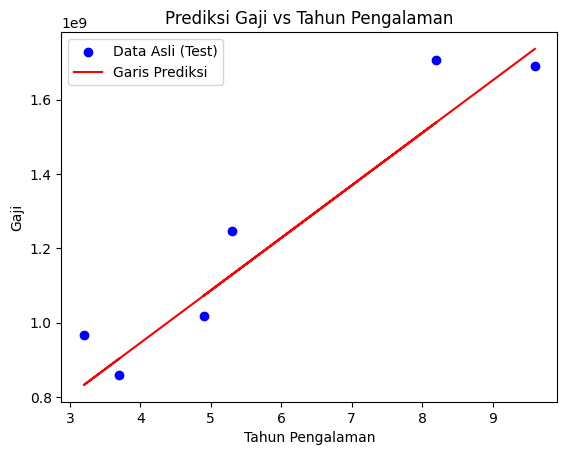

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Load Data dengan menambahkan parameter sep=';'
df_gaji = pd.read_csv('Data_Gaji.csv', sep=';')

# 2. Tentukan variabel independen (X) dan dependen (y)
# Nama kolom disesuaikan dengan isi dataset
X = df_gaji[['Tahun_Pengalaman']].values
y = df_gaji['Gaji'].values

# 3. Bagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Latih Model Linear Regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# 5. Uji Akurasi
score = linreg.score(X_test, y_test)
print(f"Akurasi Linear Regression (R2 Score): {score:.4f}")

# 6. Visualisasi Hasil
plt.scatter(X_test, y_test, color='blue', label='Data Asli (Test)')
plt.plot(X_test, linreg.predict(X_test), color='red', label='Garis Prediksi')
plt.title('Prediksi Gaji vs Tahun Pengalaman')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.legend()
plt.show()

In [2]:
print(df_gaji.columns)

Index(['Tahun_Pengalaman;Gaji'], dtype='object')
